In [1]:
import numpy as np
import scipy as sp
from scipy import signal
import control
import matplotlib.pyplot as plt

In [2]:
%matplotlib notebook

In [3]:
hp = control.tf([1, 1], [1, 1.8, 1, 0])
display(hp)

hf = control.tf(np.convolve([1, 2], [1, 3]), np.convolve([1, 4], [1, 3, 5]))
display(hf)

TransferFunction(array([1, 1]), array([1. , 1.8, 1. , 0. ]))

TransferFunction(array([1, 5, 6]), array([ 1,  7, 17, 20]))

<IPython.core.display.Javascript object>


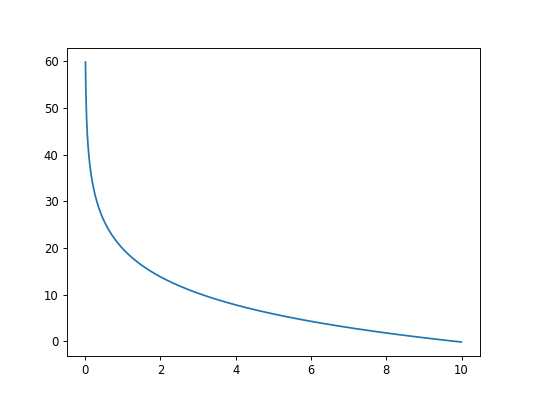

In [65]:
lampl = []
lfaza = []
lpreg = []
irange = np.array(range(1000))/100
for i in irange:
    lampl.append(20*np.log(list(control.margin(i * hp * hf))[0])/np.log(10))
    lfaza.append(list(control.margin(i * hp * hf))[1])
    if i != 0:
        lpreg.append(control.step_info((i * hp).feedback(hf))['Overshoot'])
plt.plot(irange, lampl)

In [51]:
lampl.sort(reverse = True)
for i in range(len(lampl)):
    if lampl[i]<10:
        print(i/100)
        break

3.12


In [ ]:
#По амплитуде получаем, что к меньше примерно 3.12

<IPython.core.display.Javascript object>


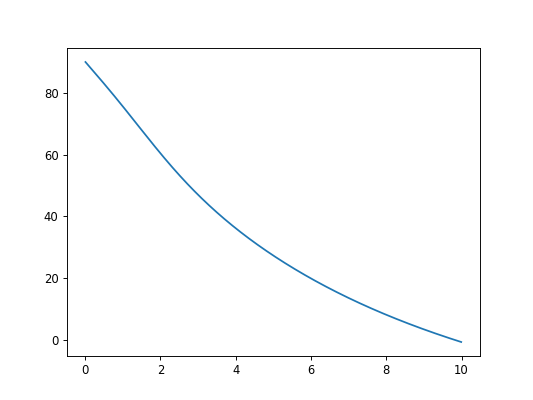

In [54]:
plt.plot(irange, lfaza)

In [55]:
lfaza.sort(reverse = True)
for i in range(len(lfaza)):
    if lfaza[i]<30:
        print(i/100)
        break

4.69


In [ ]:
#По фазе k меньше 4.69 - более слабое неравенство, нежели по амплитуде 

<IPython.core.display.Javascript object>


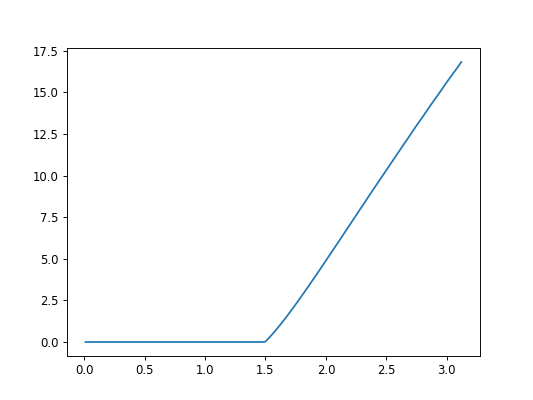

In [69]:
plt.plot(irange[1:313], lpreg[:312])

In [70]:
for i in range(1, len(lpreg)+1):
    if lpreg[i]>0.3:
        print(i/100)
        break

1.53


In [ ]:
#По перерегулированию k меньше 1.53

In [ ]:
#Следовательно, к в промежутке от 0 до 1.53 не включительно

# Задание
Для системы из `hp` в прямой цепи и `hf` в обратной подберите коэффициент усиления для `hp`, отвечающий следующим свойствам:
1. запас по фазе не менее 30 градусов,
2. запас по амплитуде не менее 10 дБ,
3. перерегулирование не более 30%.